<a href="https://colab.research.google.com/github/imke-kilab/foci-counting/blob/main/foci_counting_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FOCI Dataset – Object Counting Notebook

This notebook demonstrates two approaches for solving the **object counting task** on the [FOCI dataset](https://zenodo.org/records/19222986).


| # | Approach | Idea |
|---|----------|------|
| 1 | **YOLO** (Ultralytics) | Detect individual foci with bounding boxes, then count detections |
| 2 | **U-Net Density Map** | Regress a density map and integrate it to obtain the count (more details in code section) |

The FOCI dataset contains 446 fluorescence microscopy images of irradiated cells. Foci represent sites of radiation-induced DNA double-strand breaks. These appear as red fluorescent spots within blue-stained nuclei. The distribution of the number of Foci per cell can be used to estimate radiation exposure. More details can be found [here](https://zenodo.org/records/19222986).

**Prerequisites**
- Data is pre-cropped and split into `train / val / test` (as provided on [Kaggle](https://www.kaggle.com/datasets/imkevoss/cell-foci)).
- No image rewriting is performed.



## Setup


In [1]:
# If your environment is missing packages, uncomment and run:
%pip install -q ultralytics torch torchvision opencv-python pillow scikit-learn pandas matplotlib pyyaml tqdm density_maps lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 658.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.4 MB/s eta 0:00:00


In [9]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Configuration

Download foci-cell dataset from huggingface.

In [3]:
!git lfs install
!git clone https://huggingface.co/datasets/Im-KI/cell-foci

Git LFS initialized.
Cloning into 'cell-foci'...
remote: Enumerating objects: 1690, done.
remote: Counting objects: 100% (1686/1686), done.
remote: Compressing objects: 100% (949/949), done.
remote: Total 1690 (delta 712), reused 1671 (delta 706), pack-reused 4 (from 1)
Receiving objects: 100% (1690/1690), 214.00 KiB | 6.29 MiB/s, done.
Resolving deltas: 100% (712/712), done.
Filtering content: 100% (446/446), 61.82 MiB | 6.10 MiB/s, done.


In [10]:
DATA_ROOT = Path("cell-foci")

YOLO_DATA_YAML = DATA_ROOT / "foci.yaml"

from ultralytics.utils import LOGGER
LOGGER.disabled = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Data root: {DATA_ROOT}")

Device: cpu
Data root: cell-foci


## Helpers
A few small utilities shared by both approaches.

In [11]:
def get_image_paths(split: str) -> list[Path]:
    """Return sorted list of .TIF images for a given split."""
    return sorted((DATA_ROOT / "images" / split).glob("*.TIF"))

def read_xyxy_boxes(image_path: Path) -> list[list[int]]:
    """Read ground-truth bounding boxes (xyxy) from the JSON label file."""
    label = DATA_ROOT / "labels" / "xyxy" / f"{image_path.stem}.json"
    if not label.exists():
        return []
    with label.open() as f:
        return json.load(f).get("bboxes", [])

def count_metrics(y_true, y_pred) -> dict[str, float]:
    """Compute MAE, RMSE, MAPE and bias for count predictions."""
    yt = np.asarray(y_true, dtype=float).ravel()
    yp = np.asarray(y_pred, dtype=float).ravel()
    return {
        "MAE":        float(np.mean(np.abs(yt - yp))),
        "RMSE":       float(np.sqrt(np.mean((yt - yp) ** 2))),
        "MAPE":       float(np.mean(np.abs(yt - yp) / (yt + 1.0))),
        "Bias":       float(np.mean(yt - yp)),
        "Mean Count": float(np.mean(yt)),
    }

def read_center_points(image_path: Path) -> list[list[float]]:
    """Read ground-truth center points from the JSON label file."""
    label = DATA_ROOT / "labels" / "dots" / f"{image_path.stem}.json"
    if not label.exists():
        return []
    with label.open() as f:
        return json.load(f).get("center", [])

### Visualise a few training samples

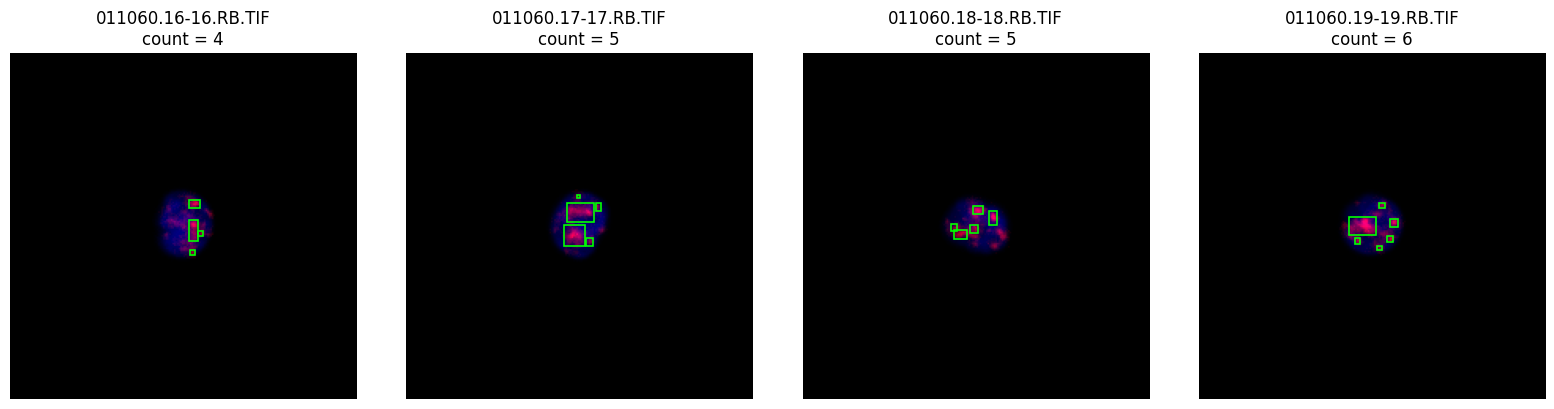

In [12]:
def show_samples(split: str = "train", n: int = 4):
    paths = get_image_paths(split)[:n]
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        boxes = read_xyxy_boxes(p)
        for x1, y1, x2, y2 in boxes:
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           fill=False, edgecolor="lime", lw=1.2))
        ax.set_title(f"{p.name}\ncount = {len(boxes)}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples()

## Approach 1: YOLO Object Detection (Ultralytics)

We fine-tune a lightweight YOLOv8-nano pretrained model in **single-class** mode.  
After training, each detected bounding box counts as one foci.

In [ ]:
yolo_model = YOLO("yolov8n.pt", verbose=False)
yolo_model.train(
    data=str(YOLO_DATA_YAML),
    epochs=50,
    batch=8,
    patience=12,
    workers=4,
    pretrained=True,
    single_cls=True,
    device=0 if DEVICE.type == "cuda" else "cpu",
    save=True,
    plots=False,
    verbose=False,
)

print("YOLO training complete.")

train: Scanning /content/cell-foci/labels/train... 227 images, 80 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 284/284 725.2it/s 0.4s
val: Scanning /content/cell-foci/labels/val... 15 images, 60 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 2.0Kit/s 0.0s
       1/50         0G       3.13      4.748      1.248         10        640: 100% ━━━━━━━━━━━━ 36/36 6.7s/it 4:01
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.3s/it 21.7s
       2/50         0G      2.789      3.054      1.026         29        640: 100% ━━━━━━━━━━━━ 36/36 6.3s/it 3:46
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.4s/it 22.2s
       3/50         0G      2.616       2.71      1.025         15        640: 100% ━━━━━━━━━━━━ 36/36 6.4s/it 3:52
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.2s/it 21.2s
       4/50         

### YOLO – Evaluation on the test split

In [ ]:
def evaluate_yolo_counts(model: YOLO) -> tuple[pd.DataFrame, dict[str, float]]:
    test_images = get_image_paths("test")
    preds = model.predict(
        source=[str(p) for p in test_images],
        iou=0.05,
        batch=min(16, len(test_images)),
        device=0 if DEVICE.type == "cuda" else "cpu",
        verbose=False,
    )

    rows = []
    for image_path, pred in zip(test_images, preds):
        gt = len(read_xyxy_boxes(image_path))
        pred = 0 if pred.boxes is None else int(pred.boxes.xyxy.shape[0])
        rows.append(dict(image=image_path.name, gt=gt, pred=pred, abs_err=abs(gt - pred)))
    df = pd.DataFrame(rows)
    return df, count_metrics(df["gt"].to_numpy(), df["pred"].to_numpy())


yolo_df, yolo_metrics = evaluate_yolo_counts(yolo_model)
print("YOLO test metrics:")
for k, v in yolo_metrics.items():
    print(f"  {k:12s}: {v:.3f}")

### YOLO – Qualitative results

In [ ]:
def plot_yolo_predictions(model: YOLO, n: int = 4):
    paths = get_image_paths("test")[:n]
    preds = model.predict(source=[str(p) for p in paths],
                          conf=0.25, iou=0.05, verbose=False)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    axes = np.atleast_1d(axes)
    for ax, p, det in zip(axes, paths, preds):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        # Ground truth (green)
        for x1, y1, x2, y2 in read_xyxy_boxes(p):
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                           fill=False, edgecolor="lime", lw=1))
        # Predictions (red)
        n_pred = 0
        if det.boxes is not None:
            for x1, y1, x2, y2 in det.boxes.xyxy.cpu().numpy():
                ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                               fill=False, edgecolor="red", lw=1))
                n_pred += 1
        ax.set_title(f"GT={len(read_xyxy_boxes(p))} | Pred={n_pred}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_yolo_predictions(yolo_model)

## Approach 2: U-Net Density Map Regression
Instead of detecting individual objects we train a U-Net to predict a
**density map**. Each center point is convolved with a Gaussian to create the ground truth density map. Summing the density map yields the count.

We use the lightweight [`density_maps`](https://pypi.org/project/density-maps/) library together with
PyTorch Lightning.

In [ ]:
import albumentations as A
import lightning as L
from lightning.pytorch.loggers import CSVLogger

from density_maps import DensityMapGenerator, DensityMapTransform, DensityMapLoss, count_mae
from density_maps.models import Unet

L.pytorch.seed_everything(0, workers=True)

Seed set to 0


0

### Dataset & Transforms


In [ ]:
class DensityDataset(torch.utils.data.Dataset):
    def __init__(self, split: str, transform: DensityMapTransform):
        self.img_paths = get_image_paths(split)
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index: int):
        img_path = self.img_paths[index]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        keypoints = read_center_points(img_path)

        img, densitymap = self.transform(image=img, keypoints=keypoints)
        return img, densitymap


In [ ]:
# Normalisation values (precomputed from the training split)
NORM_MEAN = [0, 0, 0]
NORM_STD  = [0.03129919245839119, 2.6015322873718105e-07, 0.07123438268899918]

train_compose = A.Compose(
    [A.Resize(224, 224),
     A.Normalize(NORM_MEAN,NORM_STD),
     A.SquareSymmetry(p=0.5),
     A.Rotate(90, p=0.5),
     A.ToTensorV2(),
    ], keypoint_params=A.KeypointParams(format="xy"))
val_compose = A.Compose(
    [A.Resize(224, 224),
     A.Normalize(NORM_MEAN,NORM_STD),
     A.ToTensorV2(),
    ], keypoint_params=A.KeypointParams(format="xy"))

generator = DensityMapGenerator(alpha_scaling=1, sigma=2.25)
train_transform = DensityMapTransform(albu_transform=train_compose, density_generator=generator)
val_transform = DensityMapTransform(albu_transform=val_compose, density_generator=generator)

In [ ]:
train_dataset = DensityDataset("train", transform=train_transform)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)

val_dataset = DensityDataset("val", transform=val_transform)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)

test_dataset = DensityDataset("test", transform=val_transform)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

### Lightning Module

In [ ]:
class DensityMapLightningModule(L.LightningModule):
    def __init__(self, model: torch.nn.Module, loss: DensityMapLoss):
        super().__init__()
        self.model = model
        self.loss = loss
        self.generator = loss.generator

    def _eval(self, batch, prefix):
        imgs, dmap = batch
        pred_dmap = self.model(imgs)
        loss = self.loss(pred_dmap, dmap)
        gt_count = self.generator.to_count(dmap)
        pred_count = self.generator.to_count(pred_dmap)
        mae = count_mae(pred_count, gt_count)
        self.log(f"{prefix}_loss", loss, prog_bar=True)
        self.log(f"{prefix}_MAE", mae, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        imgs, dmap = batch
        pred_dmap = self.model(imgs)
        loss = self.loss(pred_dmap, dmap)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        self._eval(batch, "val")
        return loss

    def test_step(self, batch, batch_idx):
        self._eval(batch, "test")
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=3e-3, betas=(0.83, 0.85))
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",  # ReduceLROnPlateau requires this
                "interval": "epoch",
            }
        }

### Density Map - Training

In [ ]:
model = Unet(hidden_dims=[32,64,128,256],input_channels=3, output_channels=1)
loss = DensityMapLoss(generator=generator, lambda_count=0.008)
counter = DensityMapLightningModule(model=model, loss=loss)

trainer = L.Trainer(max_epochs=100, devices=1, accelerator="auto", enable_progress_bar=True, logger=CSVLogger("."))
trainer.fit(model=counter, train_dataloaders=trainloader, val_dataloaders=valloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Unet           │  4.6 M │ train │     0 │
│ 1 │ loss  │ DensityMapLoss │      0 │ train │     0 │
└───┴───────┴────────────────┴────────┴───────┴───────┘

Trainable params: 4.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.6 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 76                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(36) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=100` reached.


### Density Map – Evaluation on the test split


In [ ]:
results = trainer.test(model=counter, dataloaders=testloader, verbose=True)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MAE          │    0.8546987175941467     │
│         test_loss         │    0.01136863324791193    │
└───────────────────────────┴───────────────────────────┘

### Density Map – Qualitative results
Rows: original image · ground-truth density · predicted density

Columns: image samples

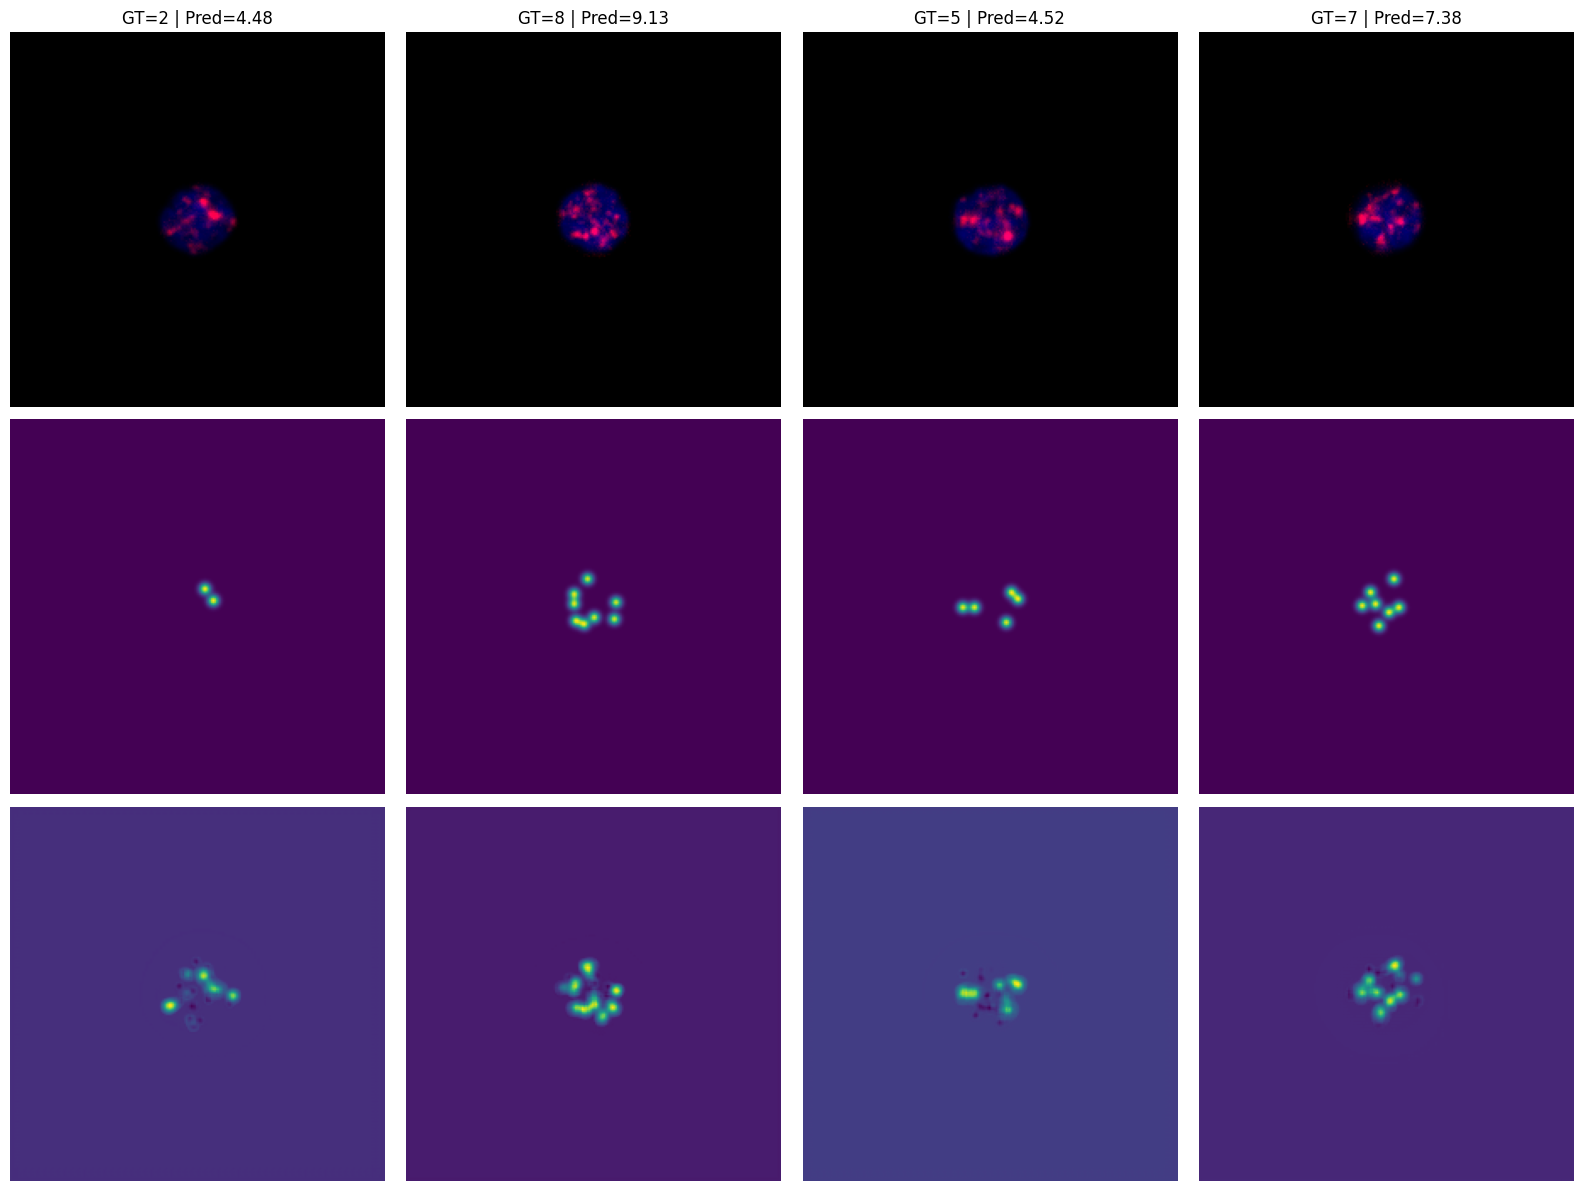

In [ ]:
def plot_density_map_predictions(model: torch.nn.Module, dataset: torch.utils.data.Dataset, generator:DensityMapGenerator, n: int = 4):
    imgs, dmaps_gt = zip(*(dataset[i] for i in range(n)))
    dmaps_gt = torch.stack(dmaps_gt)

    with torch.no_grad():
        dmaps_pred = model(torch.stack(imgs, dim=0))

    fig, axes = plt.subplots(nrows=3, ncols=len(imgs), figsize=(4 * len(imgs), 12))

    for idx in range(n):
        img_path = str(dataset.img_paths[idx])
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        gt  = generator.to_count(dmaps_gt[idx]).item()
        pred = generator.to_count(dmaps_pred[idx]).item()

        axes[0, idx].imshow(img)
        axes[1,idx].imshow(dmaps_gt[idx].squeeze())
        axes[2,idx].imshow(dmaps_pred[idx].squeeze())
        axes[0,idx].set_title(f"GT={gt:.0f} | Pred={pred:.2f}")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()


checkpoint = torch.load(trainer.checkpoint_callback.best_model_path)
counter.load_state_dict(checkpoint["state_dict"])
counter.to(device="cpu")
plot_density_map_predictions(counter.model, test_dataset, generator, n=4)